# RQ1 — Chi è il pivot strutturale di ogni semifinalista?

## Obiettivo

Questa notebook implementa la prima research question del progetto:
**identificare il giocatore strutturalmente più importante in ogni rete di 
passaggio delle quattro semifinaliste del Mondiale 2022** (Argentina, Francia, 
Croazia, Marocco).

"Importante" in network science non ha un significato unico. Utilizziamo
sei definizioni diverse di centralità, ciascuna delle quali cattura un aspetto
diverso del ruolo di un giocatore nella rete. I giocatori su cui queste
definizioni **non concordano** sono il risultato più interessante dell'analisi.

## Struttura del notebook

1. Setup e importazioni
2. Caricamento dati StatsBomb
3. Costruzione della rete di passaggio
4. Calcolo delle sei centralità
5. Correlazioni di Spearman tra le misure
6. Identificazione dei profili strutturali (Terminal / Broker / Metronome)
7. Null model — verifica statistica
8. Visualizzazioni
9. Analisi aggregata sulle quattro semifinaliste

## 1. Setup e importazioni

Importiamo le librerie necessarie:

- `statsbombpy` — accesso ai dati open di StatsBomb direttamente in Python
- `networkx` — costruzione e analisi delle reti
- `pandas` / `numpy` — manipolazione dati
- `matplotlib` / `seaborn` — visualizzazioni
- `scipy` — correlazioni di Spearman
- `mplsoccer` — disegno del campo da calcio

In [25]:
import warnings
warnings.filterwarnings("ignore")

import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import spearmanr
from statsbombpy import sb
from mplsoccer import Pitch

# Configurazione globale
COMPETITION_ID = 43    # FIFA World Cup
SEASON_ID      = 106   # edizione 2022
SEMIFINALISTS  = ["Argentina", "France", "Croatia", "Morocco"]
MIN_MINUTES    = 30    # soglia minima di minuti per includere un giocatore

# Palette colori per le squadre e per i reparti
TEAM_COLORS = {
    "Argentina": "#75AADB",
    "France":    "#002395",
    "Croatia":   "#FF0000",
    "Morocco":   "#006233",
}

LINE_COLORS = {
    "GK":      "#FFD700",
    "DEF":     "#2196F3",
    "MID":     "#4CAF50",
    "ATT":     "#F44336",
    "Unknown": "#999999",
}

print("✓ Setup completato")

✓ Setup completato


## 2. Caricamento dati StatsBomb

StatsBomb mette a disposizione gratuitamente i dati event-level del Mondiale 2022.
Ogni evento rappresenta un'azione sul campo (passaggio, tiro, conduzione, ecc.)
con timestamp, coordinate x/y sul campo (120×80 metri), e metadati specifici
per il tipo di evento.
Per questa analisi ci interessano solo gli eventi di tipo **Pass** con
`pass_outcome` nullo, che in StatsBomb indica un passaggio **completato**.

- `pass_outcome` assente → passaggio completato ✓  
- `pass_outcome` presente ("Incomplete", "Out", ecc.) → passaggio fallito ✗

Iniziamo caricando la lista di tutte le 64 partite del torneo e identificando
le partite giocate da ciascuna delle quattro semifinaliste.

In [26]:
# Carica la lista di tutte le partite del Mondiale 2022
matches = sb.matches(competition_id=COMPETITION_ID, season_id=SEASON_ID)
print(f"Totale partite nel dataset: {len(matches)}")
print(f"Colonne disponibili: {matches.columns.tolist()}\n")

# Per ogni semifinalista, mostra le partite giocate
for team in SEMIFINALISTS:
    team_matches = matches[
        (matches["home_team"] == team) |
        (matches["away_team"] == team)
    ]
    print(f"{'─'*50}")
    print(f"{team}: {len(team_matches)} partite")
    for _, m in team_matches.iterrows():
        print(f"  [{m['match_id']}] {m['home_team']} vs {m['away_team']} — {m['competition_stage']}")

Totale partite nel dataset: 64
Colonne disponibili: ['match_id', 'match_date', 'kick_off', 'home_score', 'away_score', 'match_status', 'match_status_360', 'last_updated', 'last_updated_360', 'match_week', 'competition_id', 'competition_country_name', 'competition_name', 'competition', 'season_id', 'season', 'home_team_id', 'home_team', 'home_team_gender', 'home_team_group', 'home_team_country_id', 'home_team_country_name', 'away_team_id', 'away_team', 'away_team_gender', 'away_team_group', 'away_team_country_id', 'away_team_country_name', 'competition_stage_id', 'competition_stage', 'stadium_id', 'stadium', 'stadium_country_id', 'stadium_country_name', 'referee_id', 'referee', 'referee_country_id', 'referee_country_name', 'home_managers', 'away_managers', 'home_manager_id', 'home_manager_name', 'home_manager_nickname', 'home_manager_dob', 'home_manager_country_id', 'home_manager_country_name', 'away_manager_id', 'away_manager_name', 'away_manager_nickname', 'away_manager_dob', 'away_ma

## 3. Esplorazione della struttura degli eventi

Prima di costruire la rete, esploriamo la struttura di un singolo file di eventi
usando la **finale Argentina–Francia** come caso pilota.

Ogni file di eventi contiene tutte le azioni di una partita in ordine cronologico.
Vogliamo capire:
- Quanti eventi ci sono per partita
- Quanti sono passaggi completati
- Come sono strutturati i campi `player`, `pass_recipient`, `location`

Questo passaggio esplorativo è fondamentale prima di costruire qualsiasi rete:
conoscere i dati evita errori di interpretazione nelle analisi successive.

In [27]:
# Identifica il match_id della finale
finale_row = matches[matches["competition_stage"] == "Final"]
FINALE_ID = finale_row["match_id"].values[0]
print(f"Finale: {finale_row['home_team'].values[0]} vs "
      f"{finale_row['away_team'].values[0]} (match_id = {FINALE_ID})\n")

# Carica tutti gli eventi della finale
events_finale = sb.events(match_id=FINALE_ID)
print(f"Totale eventi nella partita: {len(events_finale)}")
print(f"\nDistribuzione per tipo di evento:")
print(events_finale["type"].value_counts().head(10))

Finale: Argentina vs France (match_id = 3869685)

Totale eventi nella partita: 4407

Distribuzione per tipo di evento:
type
Pass              1263
Ball Receipt*     1114
Carry              940
Pressure           361
Ball Recovery      115
Duel                98
Dribble             54
Block               50
Foul Committed      48
Clearance           45
Name: count, dtype: int64


In [28]:
# Filtra solo i passaggi e guarda la struttura
passes_raw = events_finale[events_finale["type"] == "Pass"].copy()

print(f"Totale passaggi (tutti):      {len(passes_raw)}")
print(f"Passaggi completati:          {passes_raw['pass_outcome'].isna().sum()}")
print(f"Passaggi falliti/incompleti:  {passes_raw['pass_outcome'].notna().sum()}")

print(f"\nEsempio di un passaggio completato:")
esempio = passes_raw[passes_raw["pass_outcome"].isna()].iloc[0]
print(f"  Giocatore:    {esempio['player']}")
print(f"  Ricevitore:   {esempio['pass_recipient']}")
print(f"  Squadra:      {esempio['team']}")
print(f"  Da:           {esempio['location']}")
print(f"  A:            {esempio['pass_end_location']}")

Totale passaggi (tutti):      1263
Passaggi completati:          994
Passaggi falliti/incompleti:  269

Esempio di un passaggio completato:
  Giocatore:    Antoine Griezmann
  Ricevitore:   Aurélien Djani Tchouaméni
  Squadra:      France
  Da:           [61.0, 40.1]
  A:            [48.0, 43.2]


## 4. Costruzione della rete di passaggio

Costruiamo la rete di passaggio per l'Argentina nella finale come caso pilota.
La rete è un **grafo diretto e pesato** dove:

- **Nodi** = giocatori
- **Archi** = direzione del passaggio (da chi passa → a chi riceve)
- **Peso dell'arco** = numero di passaggi completati tra quella coppia

### La convenzione della distanza: perché 1/peso

Le misure di betweenness e closeness centrality si basano sui **cammini più corti**
nella rete. Un algoritmo di cammino più corto cerca il percorso con la **somma
minima** dei pesi degli archi.

Nel nostro caso vogliamo che due giocatori che si scambiano molti passaggi siano
considerati **vicini**. Ma se usassimo il peso direttamente, un peso alto
significherebbe distanza alta — l'opposto di quello che vogliamo.

Soluzione: definiamo `distanza = 1 / peso`. Così:
- 20 passaggi tra A e B → distanza = 0.05 (vicini)
- 2 passaggi tra C e D  → distanza = 0.50 (lontani)

Questo è il bug più comune nella letteratura sulle reti di passaggio (Peña & 
Touchette, 2012) e viene corretto esplicitamente qui.

In [29]:
def build_passing_network(team_name, events_df):
    """
    Costruisce la rete di passaggio di una squadra da un DataFrame di eventi.
    
    Parametri
    ----------
    team_name : str
        Nome della squadra (come appare in StatsBomb)
    events_df : DataFrame
        Tutti gli eventi della partita
    
    Ritorna
    -------
    G : nx.DiGraph
        Grafo diretto e pesato con attributi 'weight' e 'distance' sugli archi
    passes_df : DataFrame
        DataFrame dei passaggi completati con coordinate
    """
    
    # Filtra: solo passaggi completati della squadra
    passes = events_df[
        (events_df["type"] == "Pass") &
        (events_df["team"] == team_name) &
        (events_df["pass_outcome"].isna())
    ].copy()
    
    # Estrai coordinate
    passes["x_start"] = passes["location"].apply(
        lambda l: l[0] if isinstance(l, list) else np.nan
    )
    passes["y_start"] = passes["location"].apply(
        lambda l: l[1] if isinstance(l, list) else np.nan
    )
    passes["x_end"] = passes["pass_end_location"].apply(
        lambda l: l[0] if isinstance(l, list) else np.nan
    )
    passes["y_end"] = passes["pass_end_location"].apply(
        lambda l: l[1] if isinstance(l, list) else np.nan
    )
    
    passes_clean = passes[
        ["player", "pass_recipient", "x_start", "y_start", "x_end", "y_end"]
    ].dropna(subset=["player", "pass_recipient"]).copy()
    passes_clean.columns = ["passer", "recipient", "x_start", "y_start", "x_end", "y_end"]
    
    # Conta i passaggi per ogni coppia (passer → recipient)
    edge_weights = (
        passes_clean
        .groupby(["passer", "recipient"])
        .size()
        .reset_index(name="weight")
    )
    
    # Calcola la posizione media di ogni giocatore sul campo
    avg_pos = (
        passes_clean
        .groupby("passer")[["x_start", "y_start"]]
        .mean()
        .rename(columns={"x_start": "avg_x", "y_start": "avg_y"})
    )
    
    # Costruisci il grafo
    G = nx.DiGraph()
    
    for _, row in edge_weights.iterrows():
        G.add_edge(
            row["passer"],
            row["recipient"],
            weight=row["weight"],
            distance=1.0 / row["weight"]   # convenzione fondamentale
        )
    
    # Aggiungi posizione media come attributo del nodo
    for node in G.nodes():
        if node in avg_pos.index:
            G.nodes[node]["avg_x"] = avg_pos.loc[node, "avg_x"]
            G.nodes[node]["avg_y"] = avg_pos.loc[node, "avg_y"]
        else:
            G.nodes[node]["avg_x"] = 60.0
            G.nodes[node]["avg_y"] = 40.0
    
    return G, passes_clean


# Test sulla finale dell'Argentina
G_arg_finale, passes_arg_finale = build_passing_network("Argentina", events_finale)

print(f"Rete Argentina (finale):")
print(f"  Nodi (giocatori):  {G_arg_finale.number_of_nodes()}")
print(f"  Archi (coppie):    {G_arg_finale.number_of_edges()}")
print(f"  Passaggi totali:   {sum(d['weight'] for _,_,d in G_arg_finale.edges(data=True))}")

Rete Argentina (finale):
  Nodi (giocatori):  17
  Archi (coppie):    129
  Passaggi totali:   560


## 5. Calcolo delle sei centralità

Calcoliamo le sei misure di centralità per ogni giocatore nella rete.
Ogni misura risponde a una domanda diversa:

| Misura | Domanda | Distanza usata |
|--------|---------|----------------|
| **In-Degree pesato** | Quanti passaggi riceve? | — |
| **Out-Degree pesato** | Quanti passaggi fa? | — |
| **Betweenness** | Su quanti cammini più corti si trova? | 1/weight ✓ |
| **Closeness** | Quanto è vicino a tutti gli altri? | 1/weight ✓ |
| **Eigenvector** | È connesso a giocatori importanti? | weight |
| **PageRank** | Qual è la prob. di avere il pallone? | weight |

Le misure che usano i cammini più corti (betweenness e closeness) **devono**
usare `distance = 1/weight`. Le altre usano il peso direttamente.

In [30]:
def compute_centralities(G):
    """
    Calcola le 6 misure di centralità su un grafo diretto e pesato.
    
    Ritorna un DataFrame con una riga per giocatore e 6 colonne di centralità,
    ordinato per betweenness decrescente.
    """
    
    total_w = sum(d["weight"] for _,_,d in G.edges(data=True))
    
    # 1. In-degree pesato (normalizzato)
    in_deg = {
        n: sum(d["weight"] for _,_,d in G.in_edges(n, data=True)) / total_w
        for n in G.nodes()
    }
    
    # 2. Out-degree pesato (normalizzato)
    out_deg = {
        n: sum(d["weight"] for _,_,d in G.out_edges(n, data=True)) / total_w
        for n in G.nodes()
    }
    
    # 3. Betweenness — usa DISTANCE
    betweenness = nx.betweenness_centrality(
        G, weight="distance", normalized=True
    )
    
    # 4. Closeness — usa DISTANCE
    closeness = nx.closeness_centrality(G, distance="distance")
    
    # 5. Eigenvector — usa weight
    try:
        eigenvector = nx.eigenvector_centrality(
            G, weight="weight", max_iter=1000
        )
    except nx.PowerIterationFailedConvergence:
        eigenvector = nx.eigenvector_centrality_numpy(G, weight="weight")
    
    # 6. PageRank — usa weight
    pagerank = nx.pagerank(G, weight="weight", alpha=0.85)
    
    # Assembla in DataFrame
    df = pd.DataFrame({
        "in_degree":   in_deg,
        "out_degree":  out_deg,
        "betweenness": betweenness,
        "closeness":   closeness,
        "eigenvector": eigenvector,
        "pagerank":    pagerank,
    })
    
    return df.sort_values("betweenness", ascending=False)


# Calcola le centralità per l'Argentina nella finale
cent_arg = compute_centralities(G_arg_finale)

print("Argentina (finale) — Top 10 per betweenness:\n")
print(cent_arg.round(4).to_string())

Argentina (finale) — Top 10 per betweenness:

                                 in_degree  out_degree  betweenness  closeness  eigenvector  pagerank
Nicolás Hernán Otamendi             0.1071      0.1232       0.3625     2.8586       0.3337    0.0992
Enzo Fernandez                      0.1500      0.1411       0.3542     3.0765       0.4620    0.1435
Rodrigo Javier De Paul              0.1179      0.1018       0.1354     2.9095       0.4260    0.1038
Alexis Mac Allister                 0.0821      0.0804       0.1229     2.7193       0.2676    0.0784
Nicolás Alejandro Tagliafico        0.0571      0.0786       0.1125     2.5011       0.1948    0.0558
Lionel Andrés Messi Cuccittini      0.1071      0.0875       0.0771     2.8623       0.3680    0.1061
Marcos Javier Acuña                 0.0482      0.0339       0.0625     1.9684       0.1492    0.0506
Cristian Gabriel Romero             0.0786      0.1071       0.0250     2.6739       0.2990    0.0696
Leandro Daniel Paredes              

## 6. Correlazioni di Spearman tra le misure

La correlazione di Spearman misura quanto due misure **concordano sul ranking**
dei giocatori. A differenza della correlazione di Pearson, non assume una 
relazione lineare — confronta direttamente i ranghi (1°, 2°, 3°...).

Interpretazione:
- **ρ ≈ 1.0** → le due misure mettono i giocatori nello stesso ordine
- **ρ ≈ 0.5** → concordano circa la metà delle volte
- **ρ basso** → divergono spesso → qui si nascondono i casi interessanti

Ci aspettiamo:
- Alta correlazione tra in-degree e PageRank (entrambi misurano "chi riceve")
- Alta correlazione tra out-degree ed eigenvector (chi passa molto a giocatori centrali)
- Correlazione moderata tra betweenness e le altre (cattura qualcosa di diverso)

I giocatori nei punti di divergenza tra betweenness e degree sono i **broker**:
giocatori che non toccano necessariamente più palloni di tutti, ma che fanno
da ponte tra parti diverse della rete.


In [31]:
def compute_spearman(centralities_df):
    """
    Calcola la matrice 6x6 di correlazioni di Spearman tra le centralità.
    Ritorna un DataFrame di correlazioni e uno di p-value.
    """
    measures = ["in_degree", "out_degree", "betweenness", "closeness",
                "eigenvector", "pagerank"]
    n = len(measures)
    corr = np.zeros((n, n))
    pval = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            rho, p = spearmanr(
                centralities_df[measures[i]].values,
                centralities_df[measures[j]].values
            )
            corr[i, j] = rho
            pval[i, j] = p
    
    corr_df = pd.DataFrame(corr, index=measures, columns=measures)
    pval_df = pd.DataFrame(pval, index=measures, columns=measures)
    return corr_df, pval_df


corr_arg, pval_arg = compute_spearman(cent_arg)

print("Argentina (finale) — Matrice di Spearman:\n")
print(corr_arg.round(2).to_string())

print("\nCoppie con correlazione < 0.6 (possibili divergenze interessanti):")
measures = ["in_degree", "out_degree", "betweenness", "closeness",
            "eigenvector", "pagerank"]
for i in range(len(measures)):
    for j in range(i+1, len(measures)):
        rho = corr_arg.iloc[i, j]
        if rho < 0.6:
            print(f"  {measures[i]} vs {measures[j]}: ρ = {rho:.2f}")

Argentina (finale) — Matrice di Spearman:

             in_degree  out_degree  betweenness  closeness  eigenvector  pagerank
in_degree         1.00        0.97         0.82       0.99         0.99      0.98
out_degree        0.97        1.00         0.83       0.95         0.97      0.95
betweenness       0.82        0.83         1.00       0.80         0.80      0.82
closeness         0.99        0.95         0.80       1.00         0.98      0.96
eigenvector       0.99        0.97         0.80       0.98         1.00      0.97
pagerank          0.98        0.95         0.82       0.96         0.97      1.00

Coppie con correlazione < 0.6 (possibili divergenze interessanti):


## 7. Identificazione dei profili strutturali

In ogni squadra cerchiamo tre profili distinti. Un giocatore può soddisfare
più profili, ma tipicamente uno domina:

### Terminal
Alto in-degree e PageRank, out-degree relativamente basso.
Il pallone arriva a lui come **destinazione finale** del flusso.
Tipicamente la punta o il trequartista che finalizza.
*Esempio atteso: Messi (Argentina), Mbappé (Francia)*

### Broker  
Alta betweenness con degree moderato.
Non è chi tocca più palloni, ma è il **ponte** tra parti della rete.
Senza di lui, difesa e attacco si disconnettono.
*Esempio atteso: Fernández (Argentina), Modrić (Croazia)*

### Metronome
Alta eigenvector e out-degree, betweenness moderata.
È il **cuore del possesso** — connesso ai giocatori più importanti e
distribuisce molto, ma non fa da ponte tra reparti distanti.
*Esempio atteso: Otamendi (Argentina), Griezmann (Francia)*

L'identificazione si basa sul ranking combinato delle misure.

In [32]:
def identify_profiles(centralities_df):
    """
    Identifica i tre profili strutturali basandosi sui ranghi delle centralità.
    """
    measures = ["in_degree", "out_degree", "betweenness", "closeness",
                "eigenvector", "pagerank"]
    
    # Calcola ranghi (1 = migliore per ogni misura)
    ranks = centralities_df[measures].rank(ascending=False).astype(int)
    
    # Terminal: minimizza rango(in_degree) + rango(pagerank) - rango(out_degree)
    # (alto in-degree e pagerank, basso out-degree relativo)
    terminal_score = ranks["in_degree"] + ranks["pagerank"] - ranks["out_degree"]
    terminal = terminal_score.idxmin()
    
    # Broker: minimizza rango(betweenness)
    broker = ranks["betweenness"].idxmin()
    
    # Metronome: minimizza rango(eigenvector) + rango(out_degree)
    # escludi broker per evitare sovrapposizioni
    metro_score = (ranks["eigenvector"] + ranks["out_degree"]).drop(
        broker, errors="ignore"
    )
    metronome = metro_score.idxmin()
    
    return {
        "terminal":  terminal,
        "broker":    broker,
        "metronome": metronome,
    }


profiles_arg = identify_profiles(cent_arg)

print("Argentina (finale) — Profili strutturali:\n")
print(f"  Terminal   (destinazione del flusso): {profiles_arg['terminal']}")
print(f"  Broker     (ponte tra reparti):       {profiles_arg['broker']}")
print(f"  Metronome  (cuore del possesso):      {profiles_arg['metronome']}")

print("\nDettaglio centralità dei tre profili:")
profili_nomi = list(profiles_arg.values())
print(cent_arg.loc[profili_nomi].round(4).to_string())

Argentina (finale) — Profili strutturali:

  Terminal   (destinazione del flusso): Lionel Andrés Messi Cuccittini
  Broker     (ponte tra reparti):       Nicolás Hernán Otamendi
  Metronome  (cuore del possesso):      Enzo Fernandez

Dettaglio centralità dei tre profili:
                                in_degree  out_degree  betweenness  closeness  eigenvector  pagerank
Lionel Andrés Messi Cuccittini     0.1071      0.0875       0.0771     2.8623       0.3680    0.1061
Nicolás Hernán Otamendi            0.1071      0.1232       0.3625     2.8586       0.3337    0.0992
Enzo Fernandez                     0.1500      0.1411       0.3542     3.0765       0.4620    0.1435


## 8. Null model — verifica statistica del broker

Abbiamo identificato il broker come il giocatore con la betweenness più alta.
Ma questo risultato è **strutturalmente significativo**, o è semplicemente
perché quel giocatore tocca più palloni degli altri?

Per rispondere usiamo il **configuration model**: generiamo 100 grafi casuali
che preservano la stessa sequenza di in-degree e out-degree di ogni giocatore
(ogni giocatore mantiene lo stesso numero di passaggi in entrata e uscita),
ma con gli archi ricablati casualmente.

Se la betweenness osservata supera il **95° percentile** della distribuzione
dei 100 grafi casuali, allora il ruolo di broker è reale e non è un
artefatto del volume di passaggi.

Questo è il "sanity check" richiesto dalla sezione Expected Findings del proposal.


In [33]:
def null_model_test(G, n_realisations=100):
    """
    Testa se la betweenness massima osservata è significativa rispetto
    a un configuration model che preserva la sequenza di gradi.
    
    Ritorna la distribuzione delle betweenness massime nel null model.
    """
    in_seq  = [d for _, d in G.in_degree()]
    out_seq = [d for _, d in G.out_degree()]
    null_max_bc = []
    
    for seed in range(n_realisations):
        try:
            G_null = nx.directed_configuration_model(
                in_seq, out_seq, seed=seed
            )
            # Rimuovi multi-archi e self-loop
            G_null = nx.DiGraph(G_null)
            G_null.remove_edges_from(nx.selfloop_edges(G_null))
            
            if G_null.number_of_edges() > 0:
                bc = nx.betweenness_centrality(G_null, normalized=True)
                null_max_bc.append(max(bc.values()))
        except Exception:
            continue
    
    return null_max_bc


print("Calcolo null model (100 realizzazioni)... potrebbe richiedere ~30 secondi")
null_dist_arg = null_model_test(G_arg_finale, n_realisations=100)

# Risultato
broker_name = profiles_arg["broker"]
observed_bc = cent_arg.loc[broker_name, "betweenness"]
p95 = np.percentile(null_dist_arg, 95)
percentile_rank = np.mean([x < observed_bc for x in null_dist_arg]) * 100

print(f"\nRisultato null model — Argentina (finale):")
print(f"  Broker identificato:           {broker_name}")
print(f"  Betweenness osservata:         {observed_bc:.4f}")
print(f"  Null model — 95° percentile:   {p95:.4f}")
print(f"  Null model — media:            {np.mean(null_dist_arg):.4f}")
print(f"  Percentile del broker nel null: {percentile_rank:.0f}°")
print(f"  Risultato: {'✓ SIGNIFICATIVO' if observed_bc > p95 else '✗ non significativo'}")

Calcolo null model (100 realizzazioni)... potrebbe richiedere ~30 secondi

Risultato null model — Argentina (finale):
  Broker identificato:           Nicolás Hernán Otamendi
  Betweenness osservata:         0.3625
  Null model — 95° percentile:   0.2076
  Null model — media:            0.1487
  Percentile del broker nel null: 100°
  Risultato: ✓ SIGNIFICATIVO


## 9. Visualizzazioni

Produciamo tre figure per RQ1:

1. **Hero figure** — la rete disegnata sul campo, nodi posizionati alla 
   coordinata media dei passaggi, dimensione proporzionale alla betweenness

2. **Heatmap dei ranghi** — top-10 giocatori × 6 misure di centralità,
   colorata per rango; mostra a colpo d'occhio dove le misure concordano
   e dove divergono

3. **Null model plot** — betweenness osservata vs distribuzione del null model;
   mostra che il broker è strutturalmente reale

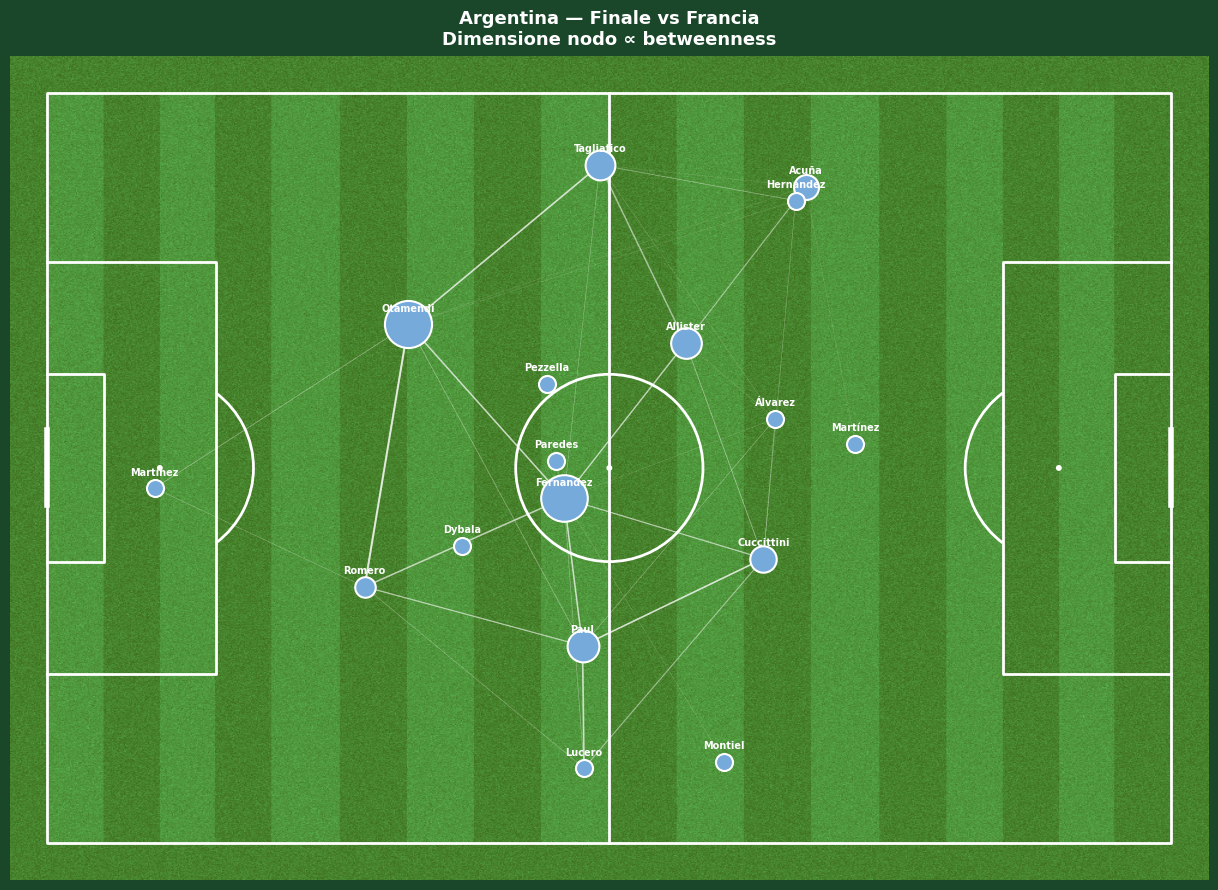

In [34]:
def plot_network_on_pitch(G, team_name, ax=None, title=None):
    """
    Disegna la rete di passaggio sul campo da calcio.
    Nodi: posizione media, dimensione ∝ betweenness, colore = reparto.
    Archi: mostrati solo se peso >= 4, spessore ∝ peso.
    """
    pitch = Pitch(
        pitch_type="statsbomb",
        pitch_color="grass",
        line_color="white",
        stripe=True
    )
    
    if ax is None:
        fig, ax = pitch.draw(figsize=(12, 8))
    else:
        pitch.draw(ax=ax)
    
    # Betweenness per dimensione dei nodi
    bc = nx.betweenness_centrality(G, weight="distance", normalized=True)
    max_bc = max(bc.values()) if bc else 1
    
    # Disegna archi
    for u, v, d in G.edges(data=True):
        if d["weight"] >= 4:
            x1 = G.nodes[u].get("avg_x", 60)
            y1 = G.nodes[u].get("avg_y", 40)
            x2 = G.nodes[v].get("avg_x", 60)
            y2 = G.nodes[v].get("avg_y", 40)
            alpha = min(d["weight"] / 25, 0.7)
            lw    = max(d["weight"] / 12, 0.4)
            ax.plot([x1, x2], [y1, y2], color="white",
                    alpha=alpha, linewidth=lw, zorder=3)
    
    # Disegna nodi
    for node in G.nodes():
        x    = G.nodes[node].get("avg_x", 60)
        y    = G.nodes[node].get("avg_y", 40)
        size = 150 + (bc.get(node, 0) / max_bc) * 1000
        color = TEAM_COLORS.get(team_name, "#888888")
        
        ax.scatter(x, y, s=size, c=color,
                   edgecolors="white", linewidth=1.5, zorder=5)
        
        short = node.split()[-1]
        ax.annotate(short, (x, y), fontsize=7, ha="center",
                    xytext=(0, 9), textcoords="offset points",
                    color="white", fontweight="bold", zorder=6)
    
    ax.set_title(title or team_name, fontsize=13,
                 fontweight="bold", color="white", pad=8)
    return ax


# Testa sulla finale dell'Argentina
fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor("#1a472a")
plot_network_on_pitch(G_arg_finale, "Argentina", ax=ax,
                      title="Argentina — Finale vs Francia\n"
                            "Dimensione nodo ∝ betweenness")
plt.tight_layout()
plt.savefig("hero_argentina_finale.png", dpi=150, bbox_inches="tight")
plt.show()

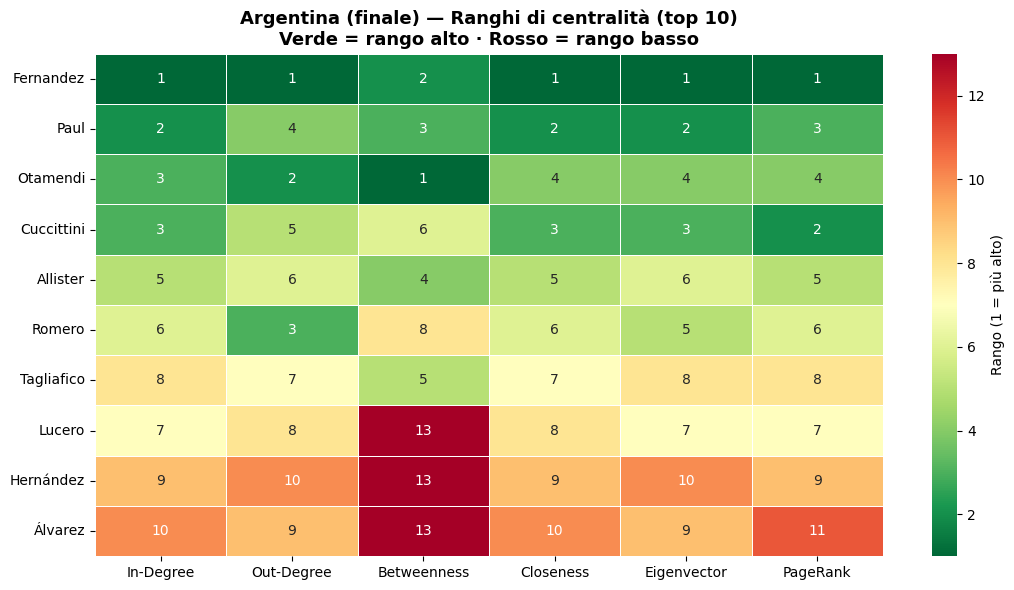

In [35]:
def plot_heatmap(centralities_df, team_name):
    """
    Heatmap dei ranghi di centralità per i top-10 giocatori.
    Celle verdi = rango alto, celle rosse = rango basso.
    Giocatori con colori uniformi sono dominanti in tutto.
    Giocatori con colori variabili hanno profili specializzati.
    """
    measures = ["in_degree", "out_degree", "betweenness", "closeness",
                "eigenvector", "pagerank"]
    labels   = ["In-Degree", "Out-Degree", "Betweenness",
                "Closeness", "Eigenvector", "PageRank"]
    
    ranks = centralities_df[measures].rank(ascending=False).astype(int)
    ranks["_total"] = ranks.sum(axis=1)
    top10 = ranks.nsmallest(10, "_total").drop(columns="_total")
    
    short_names = [n.split()[-1] for n in top10.index]
    
    fig, ax = plt.subplots(figsize=(11, 6))
    sns.heatmap(
        top10.values,
        annot=True, fmt="d",
        xticklabels=labels,
        yticklabels=short_names,
        cmap="RdYlGn_r",
        linewidths=0.5,
        cbar_kws={"label": "Rango (1 = più alto)"},
        ax=ax
    )
    ax.set_title(
        f"{team_name} — Ranghi di centralità (top 10)\n"
        f"Verde = rango alto · Rosso = rango basso",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(f"heatmap_{team_name.lower().replace(' ','_')}.png",
                dpi=150, bbox_inches="tight")
    plt.show()


plot_heatmap(cent_arg, "Argentina (finale)")

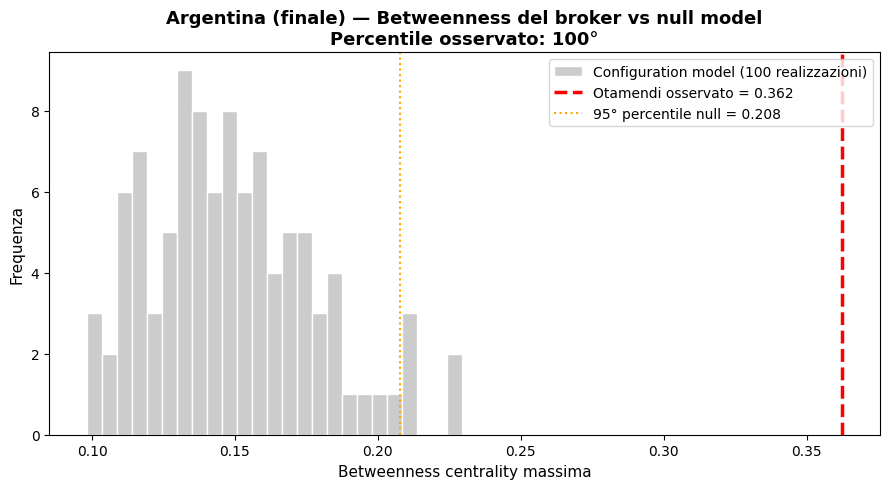

In [36]:
def plot_null_model(observed_bc, null_dist, team_name, broker_name):
    """
    Istogramma della distribuzione del null model con la betweenness
    osservata sovrapposta come linea verticale rossa.
    """
    p95  = np.percentile(null_dist, 95)
    perc = np.mean([x < observed_bc for x in null_dist]) * 100
    
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.hist(null_dist, bins=25, color="#cccccc",
            edgecolor="white", label="Configuration model (100 realizzazioni)")
    ax.axvline(observed_bc, color="red", lw=2.5, linestyle="--",
               label=f"{broker_name.split()[-1]} osservato = {observed_bc:.3f}")
    ax.axvline(p95, color="orange", lw=1.5, linestyle=":",
               label=f"95° percentile null = {p95:.3f}")
    
    ax.set_xlabel("Betweenness centrality massima", fontsize=11)
    ax.set_ylabel("Frequenza", fontsize=11)
    ax.set_title(
        f"{team_name} — Betweenness del broker vs null model\n"
        f"Percentile osservato: {perc:.0f}°",
        fontsize=13, fontweight="bold"
    )
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig(
        f"null_{team_name.lower().replace(' ','_')}.png",
        dpi=150, bbox_inches="tight"
    )
    plt.show()


plot_null_model(
    observed_bc   = cent_arg.loc[profiles_arg["broker"], "betweenness"],
    null_dist     = null_dist_arg,
    team_name     = "Argentina (finale)",
    broker_name   = profiles_arg["broker"]
)

## 10. Analisi aggregata — le quattro semifinaliste sul torneo intero

Fino a qui abbiamo lavorato sulla sola finale dell'Argentina come caso pilota.
Adesso estendiamo l'analisi a **tutte le partite del torneo** per ciascuna
delle quattro semifinaliste.

La rete aggregata somma i passaggi di tutte le partite giocate.
Applichiamo la soglia di **30 minuti** per escludere i sostituti che
hanno giocato poco e che distorcerebbero le centralità.

Il risultato finale è una tabella comparativa dei profili strutturali
delle quattro squadre.